 # **Sinthetic Argentinian DNI Generator v1**

 The goal of this notebook is generate a sinthetic example of an Argentinian DNI using fake data and our templates.

This notebook will follow the nexts steps:

* Define auxiliar functions needed for this task.
* Example of fake data with `faker`.
* Load and read the coordinates of Document elements.
* Generate an example of a *fake* DNI document.
  * Load front template.
  * Draw *fake* data in our template.
  * Choose and paste a face picture in our template.
  * Load back template.
  * Draw *fake* address in our template.
  * Draw *fake* MRZ in our template.
  * Save examples
* Generate an example of a *fake* Card Document.
  * Load front template.
  * Draw *fake* data in our template.
  * Choose and paste a face picture in our template.
  * Draw *fake* MRZ in our template. In this type of document the Machine Readable Zone is in the front.
  * Load back template.
  * Draw *fake* data in our template.
  * Save examples.
  
**IMPORTANT NOTES:**
* According to the `Registro Nacional de las Personas`(RENAPER) the following typography are used to load the biography data on the Argentinian Document come from *Sans-Serif* family (more especifically Arial or Helvetica). And for the Machine Readable Zone according to de international normative *(ICAO Doc 9303)* is used the typography called *OCR-B*, because is a monospaced typography designed to avoid errors or problems in OCR systems.
* So to do this notebook is necessary download the follows typography:
  * Arial Bold
  * arial
  * ocrb
* These `.ttf` files are in the *root* of this project in a folder called `/fonts`.
* Each piece of data is drawn strictly in uppercase according to RENAPER.
* For the faces, we use a public dataset calle `Flickr-Faces-HQ`.
* Are **excluded** of the scope of this task the safety measures printer by RENAPER to prevent the falsification of a document. This is not necessary in our case because the goal of this notebook is generate a first example of sinthetic Argentinian Document to train an object detector.  

 ## **Libraries**

In [1]:
from faker import Faker
from datetime import datetime, timedelta
from pprint import pprint
from PIL import Image, ImageDraw, ImageFont, ImageOps
from typing import List
import random
import matplotlib.pyplot as plt
import json
import os

WEIGHTS = [7, 3, 1]
MIN_FAKE_DNI = 10_000_000
MAX_FAKE_DNI = 49_999_999
MIN_FAKE_TRAMITE = 10_000_000
MAX_FAKE_TRAMITE = 99_999_999
OFFICE_CODES = ["8504", "8420", "9874", "7430", "1234", "5678", "9012", "3456", "7890", "4321", "8765", "2109", "6543", "0987", "3210", "7654", "1098", "5432", "9876", "4321"]
NRO_OFFICE_CODES = len(OFFICE_CODES)
FACES_DATA = "../../data/Flickr-Faces-HQ"

print(f"PIL version: {Image.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")

PIL version: 12.3.0
Matplotlib version: 3.11.0


* Auxiliar functions

In [2]:
def char_value(c):
    if c.isdigit():
        return int(c)
    elif c == "<":
        return 0
    elif c.isalpha():
        return ord(c.upper()) - ord("A") + 10  
    else:
        return 0

def checksum(field):
    total = sum(char_value(c) * WEIGHTS[i % 3] for i, c in enumerate(field))
    return str(total % 10)

def random_date(start_year, end_year):
    start = datetime(start_year, 1, 1)
    end = datetime(end_year, 12, 31)

    days = (end - start).days
    d = start + timedelta(days=random.randint(0, days))

    return d

def mrz_date(date):
    return date.strftime("%y%m%d")

def pad(text, length):
    text = text.upper().replace(" ", "<")
    return (text + "<" * length)[:length]

* Create an instance of *Faker* class with the argentinian code

In [3]:
fake = Faker("es_AR")

**Functions to generate fake personal data** for our sinthetics examples

In [235]:
def generate_fake_name(fake: Faker) -> str:
    """ Generate a fake name with Faker library

    Args:
        fake (Faker): An instance of the Faker class

    Returns:
        str: A complete fake name (first and last name)
    """
    name = fake.name()
    if "." in name:
        name = name.split(".")[1].strip()
    return name

def generate_fake_address(fake: Faker) -> str:
    """Generate a fake address with Faker library"""
    return fake.address().replace("\n", " - ").upper()

def get_parts_of_name(name: str) -> tuple[str, str]:
    """ Splits a full name into first and last name parts"""
    parts = name.split(" ")
    if len(parts) == 2:
        return parts[0], parts[1]
    elif len(parts) == 3:
        return " ".join(parts[0:2]), parts[2]
    elif len(parts) == 4:
        return " ".join(parts[0:2]), " ".join(parts[2:4])
    elif len(parts) > 4:
        return " ".join(parts[0:2]), " ".join(parts[2:])
    else:
        raise ValueError(f"Name has unexpected number of parts: {name}")
    
def generate_fake_dni() -> str:
    """ Generates a fake DNI (Documento Nacional de Identidad) for Argentine IDs

    Returns:
        str: A fake DNI as a string
    """
    fake_dni = random.randint(MIN_FAKE_DNI, MAX_FAKE_DNI)
    fake_dni_str = str(fake_dni)

    if len(fake_dni_str) == 8:
        dni = fake_dni_str[0:2] + "." + fake_dni_str[2:5] + "." + fake_dni_str[5:8]

    if len(fake_dni_str) == 7:
        dni = fake_dni_str[0:1] + "." + fake_dni_str[1:4] + "." + fake_dni_str[4:7]
    return dni   
    
def generate_fake_tramite_number() -> str:
    """ Generates a fake 'numero de tramite' for Argentine IDs

    Returns:
        str: A fake 'numero de tramite' as a string prefixed with '00'
    """
    return "00" + str(random.randint(MIN_FAKE_TRAMITE, MAX_FAKE_TRAMITE))

def get_random_office_code() -> str:
    """ Returns a random office code.

    Returns:
        str: A random office code
    """
    return random.choice(OFFICE_CODES)

def generate_fake_mrz(document: str,
                      first_name: str,
                      last_name: str,):
    """ Generates a fake MRZ (Machine Readable Zone) for an Argentine ID following
    the ICAO 9303(TD1) standard. The MRZ consists of three lines, with 30 characters each.

    Args:
        document (str): _description_
        first_name (str): _description_
        last_name (str): _description_

    Returns:
        str: The generated MRZ as a string with three lines.
    """
    document = document.replace(".", "")
    dock_check = checksum(document)
    
    birth_date = random_date(1950, 2010)
    birth_date_str = mrz_date(birth_date)
    birth_date_check = checksum(birth_date_str)
    
    expiration_date = random_date(2027, 2037)
    expiration_date_str = mrz_date(expiration_date)
    expiration_date_check = checksum(expiration_date_str)
    
    sex = random.choice(["M", "F"])
    
    # Line 1
    line1 = ("I<" + "ARG" + document + dock_check)
    line1 = pad(line1, 30)
    
    # Line 2
    optional = "<" * 11
    partial = (birth_date_str + birth_date_check + sex + expiration_date_str + expiration_date_check + "ARG" + optional)
    final_check = checksum(document + dock_check + birth_date_str + birth_date_check + expiration_date_str + expiration_date_check)

    line2 = pad(partial + final_check, 30)

    # Line 3
    line3 = pad(f"{last_name}<<{first_name}", 30)
    
    return line1 + "\n" + line2 + "\n" + line3

* Example of *fake* data

In [8]:
for i in range(10):
    name = generate_fake_name(fake)
    first_name, last_name = get_parts_of_name(name)
    dni = generate_fake_dni()
    tramite_number = generate_fake_tramite_number()
    office_code = get_random_office_code()
    address = generate_fake_address(fake)
    mrz = generate_fake_mrz(dni, first_name, last_name)
    print(f"First name: {first_name}, Last name: {last_name}, DNI: {dni}, Tramite Number: {tramite_number}, Office Code: {office_code}, Address: {address}")
    print(f"MRZ:\n{mrz}\n\n\n")

First name: Catalina, Last name: Sanchez, DNI: 43796026, Tramite Number: 0060713682, Office Code: 3456, Address: DIAGONAL G. BROWN N° 17 DTO. 1 - CHILECITO 5360, LA RIOJA
MRZ:
I<ARG437960267<<<<<<<<<<<<<<<<
7109094M3710184ARG<<<<<<<<<<<8
SANCHEZ<<CATALINA<<<<<<<<<<<<<



First name: Juan David, Last name: Manuel Rojas Romero, DNI: 45196132, Tramite Number: 0076360587, Office Code: 4321, Address: CALLE LA RIOJA N° 2844 - SAN MIGUEL DE TUCUMÁN 4000, TUCUMÁN
MRZ:
I<ARG451961323<<<<<<<<<<<<<<<<
8311070F2811095ARG<<<<<<<<<<<8
MANUEL<ROJAS<ROMERO<<JUAN<DAVI



First name: Pedro Milo, Last name: Fernandez Gutierrez, DNI: 32770354, Tramite Number: 0043731018, Office Code: 7890, Address: BOULEVARD 4 N° 667 PISO 9 DTO. 6 - SANTA FE 3000, SANTA FE
MRZ:
I<ARG327703543<<<<<<<<<<<<<<<<
7811285M3705018ARG<<<<<<<<<<<8
FERNANDEZ<GUTIERREZ<<PEDRO<MIL



First name: Francesco, Last name: Duarte, DNI: 24498621, Tramite Number: 0043223184, Office Code: 6543, Address: AV. NEUQUÉN N° 323 - CORRIENTES 3400, C

## **Example of a sinthetic front of DNI Document**

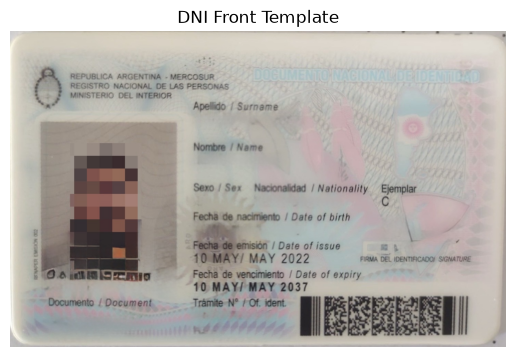

In [289]:
DNI_FRONT = "../../data/templates/front_1.jpg"

img = Image.open(DNI_FRONT)

plt.imshow(img)
plt.title("DNI Front Template")
plt.axis("off")  
plt.show()

* Load the *coords_data.json* as a dictionary

In [6]:
with open('./config/coords_data.json', 'r', encoding='utf-8') as json_data:
    coords_data = json.load(json_data)

pprint(coords_data)

{'card': {'back': {'ADDRESS_COORD': [[0.16997792494481237, 0.08916323731138547],
                                     [0.6181015452538632, 0.12345679012345678]],
                   'COUNTRY_COORD': [[0.3598233995584989, 0.6310013717421125],
                                     [0.45474613686534215, 0.8916323731138546]],
                   'NRO_TRAMITE_COORD': [[0.06622516556291391,
                                          0.6742112482853223],
                                         [0.25165562913907286,
                                          0.7133058984910837]]},
          'front': {'DOCUMENT_NUMBER_COORD': [[0.043772383605252686,
                                               0.39936908517350156],
                                              [0.31834460803820136,
                                               0.4416403785488959]],
                    'FIRST_NAME_COORD': [[0.043772383605252686,
                                          0.23659305993690852],
                     

* Defined a function to transform our relative coordinates (x, y) on absolute coordinates.

In [290]:
def to_fixed(img: Image, coords: List[List[float]]) -> List[List[int]]:
    """  Converts relative coordinates to absolute pixel coordinates based on the image size.

    Args:
        img (Image): The PIL Image object.
        coords (List[List[float]]): A list of relative coordinates (as fractions of the image dimensions).

        
    Returns:
        List[List[int]]: A list of absolute pixel coordinates.
    """
    return [[int(a * img.size[0]), int(b * img.size[1])] for a, b in coords] 


def draw_text_with_spacing(draw: ImageDraw,
                           text: str,
                           position: List[int],
                           font: ImageFont,
                           fill: tuple[int, int, int],
                           spacing: int):
    """Draw text with custom spacing between characters.

    Args:
        draw (ImageDraw): _description_
        text (str): _description_
        position (List[int]): _description_
        font (ImageFont): _description_
        fill (tuple[int, int, int]): _description_
        spacing (int): _description_
    """
    x,y = position
    for char in text:
        draw.text((x, y), char, fill=fill, font=font)
        char_width = font.getbbox(char)[2] - font.getbbox(char)[0]
        x += char_width + spacing

def draw_field(draw: ImageDraw,
               text: str,
               position: List[int],
               font: ImageFont,
               fill: tuple[int, int, int, int]):
    """Draw text in an specific position on the image.

    Args:
        draw (ImageDraw): _description_
        text (str): _description_
        position (List[int]): _description_
        font (ImageFont): _description_
        fill (tuple[int, int, int, int]): _description_
    """
    draw.text(position, text, fill=fill, font=font)

## **Complete the front data of a DNI**

In this step, we will complete te data (fake data generated by `faker`) in their correct places.

* First generate a *fake user* to show how the document would look.
* Second choose a image from our `Flick-Faces-HQ` dataset.

In [9]:
user = generate_fake_name(fake)
print(f"Generated user: {user}")

Generated user: Martina Renata Villalba


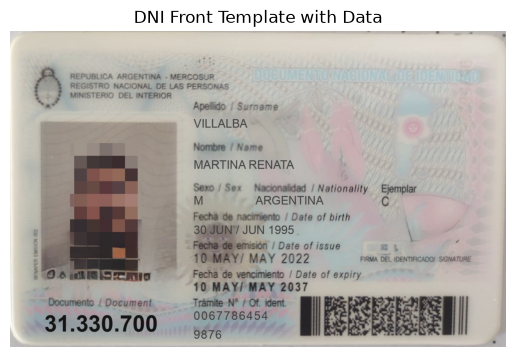

In [ ]:
font = ImageFont.truetype("../../fonts/arial.ttf", size=34)
font_bold = ImageFont.truetype("../../fonts/arial.ttf", size=34)
font_document_number = ImageFont.truetype("../../fonts/Arial Bold.ttf", size=66)
img = Image.open(DNI_FRONT).convert("RGBA")
draw = ImageDraw.Draw(img)

# First name 
first_name, last_name = get_parts_of_name(user)
absolute_coords = to_fixed(img, coords_data['dni']['front']['FIRST_NAME_COORD'])
draw_field(draw=draw,
           text=first_name.upper(),
           position=(absolute_coords[0][0], absolute_coords[0][1]),
           font=font_bold,
           fill=(20, 20, 20, 205))

# Last name
absolute_coords = to_fixed(img, coords_data['dni']['front']['LAST_NAME_COORD'])
draw_field(draw=draw,
           text=last_name.upper(),
           position=(absolute_coords[0][0], absolute_coords[0][1]),
           font=font_bold,
           fill=(20, 20, 20, 205))

# Sex
absolute_coords = to_fixed(img, coords_data['dni']['front']['SEX_COORD'])
draw_field(draw=draw,
           text=random.choice(["M", "F"]),
           position=(absolute_coords[0][0], absolute_coords[0][1]),
           font=font_bold,
           fill=(20, 20, 20, 205))

# Nationality
absolute_coords = to_fixed(img, coords_data['dni']['front']['NATIONALITY_COORD'])
draw_field(draw=draw,
           text="ARGENTINA",
           position=(absolute_coords[0][0], absolute_coords[0][1]),
           font=font_bold,
           fill=(20, 20, 20, 205))

# Birth Date
absolute_coords = to_fixed(img, coords_data['dni']['front']['BIRTH_DATE_COORD'])
draw_field(draw=draw,
           text="30 JUN / JUN 1995",
           position=(absolute_coords[0][0], absolute_coords[0][1]),
           font=font_bold,
           fill=(20, 20, 20, 205))

# Document number
document_number = generate_fake_dni()
absolute_coords = to_fixed(img, coords_data['dni']['front']['DOCUMENT_NUMBER_COORD'])
draw_field(draw=draw,
           text=document_number,
           position=(absolute_coords[0][0], absolute_coords[0][1]),
           font=font_document_number,
           fill=(20, 20, 20))

# Tramite number
tramite_number = generate_fake_tramite_number()
absolute_coords = to_fixed(img, coords_data['dni']['front']['NRO_TRAMITE_COORD'])
draw_text_with_spacing(draw=draw,
                       text=tramite_number,
                       position=(absolute_coords[0][0], absolute_coords[0][1]),
                       font=font_bold,
                       fill=(20, 20, 20, 205),
                       spacing=3
)

# Office code
office_code = get_random_office_code()
absolute_coords = to_fixed(img, coords_data['dni']['front']['OFFICE_CODE_COORD'])
draw_text_with_spacing(draw=draw,
                       text=office_code,
                       position=(absolute_coords[0][0], absolute_coords[0][1]),
                       font=font_bold,
                       fill=(20, 20, 20, 205),
                       spacing=2
)

plt.imshow(img) 
plt.title("DNI Front Template with Data")
plt.axis("off")
plt.show()   

### **Paste a face**

Now, we will paste a face picture in our template.

* First choose one picture from our public dataset.
* Resize the picture and paste in our template.

Image shape (512, 512)


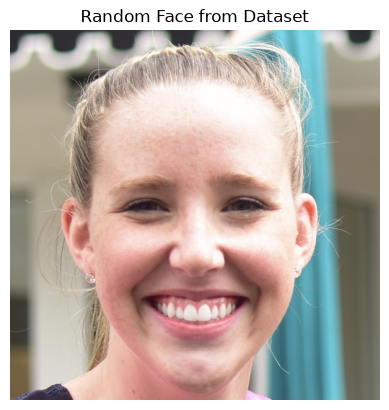

In [192]:
faces = os.listdir(FACES_DATA)

# Choose a random face
face = os.path.join(FACES_DATA, random.choice(faces))
# face_img = Image.open(face)
face_img = Image.open(face).convert("RGBA")
print(f"Image shape {face_img.size}")
plt.imshow(face_img)
plt.title("Random Face from Dataset")
plt.axis("off")
plt.show()

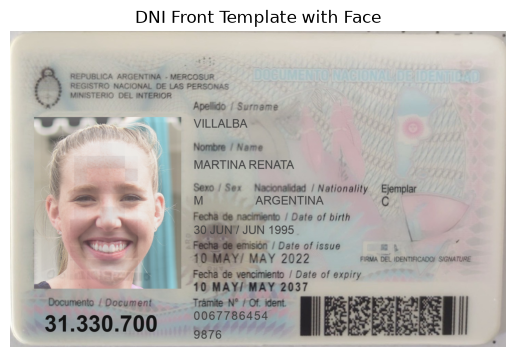

In [293]:
absolute_coords = to_fixed(img, coords_data['dni']['front']['PICTURE_COORD'])

x1, y1 = absolute_coords[0]
x2, y2 = absolute_coords[1]
target_w, target_h = x2 - x1, y2 - y1

# Resize the face image + Center crop to fit the target area
face_img_a = ImageOps.fit(image=face_img.copy(),
                        size=(target_w, target_h),
                        method=Image.Resampling.LANCZOS,
                        centering=(0.5, 0.5))

# Paste the face image onto the DNI template
# img.paste(face_img, (x1, y1))
alpha = face_img_a.split()[3].point(lambda a: int(a * 0.8))
face_img_a.putalpha(alpha)
img.paste(face_img_a, (x1, y1), face_img_a)

plt.imshow(img)
plt.title("DNI Front Template with Face")
plt.axis("off")
plt.show()

* Save this example

In [251]:
img.save("../../data/prc/synthetic_examples/dni_front.png", format="PNG")

## **Complete the back data of a DNI**

In this step, we will complete te data of the back of the document ID (fake data generated by `faker`) in their correct places.


* In first place, show the empty template.
* Put the data in their correct places (MRZ, Address)

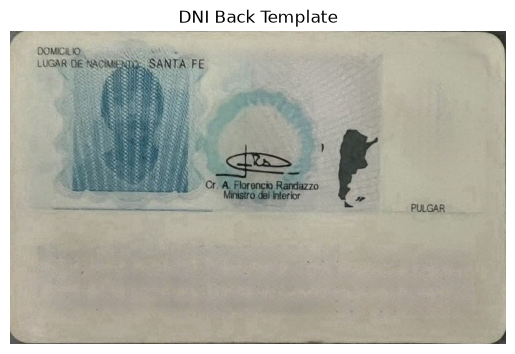

In [294]:
DNI_BACK = "../../data/templates/back_1.jpg"

img = Image.open(DNI_BACK)

plt.imshow(img)
plt.title("DNI Back Template")
plt.axis("off")  
plt.show()

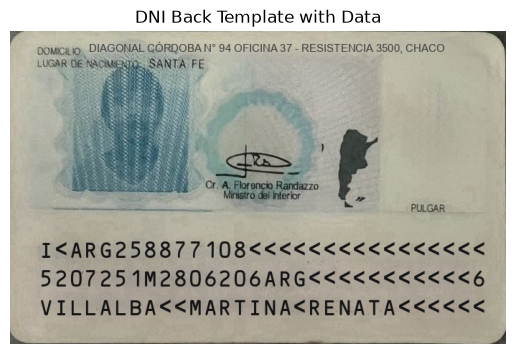

In [ ]:
font = ImageFont.truetype("../../fonts/arial.ttf", size=15)
ocrb_font = ImageFont.truetype("../../fonts/ocrb.ttf", size=40)
img = Image.open(DNI_BACK).convert("RGBA")
draw = ImageDraw.Draw(img)

# Address
address = generate_fake_address(fake)
absolute_coords = to_fixed(img, coords_data['dni']['back']['ADDRESS_COORD'])
draw_field(draw=draw,
           text=address.upper(),
           position=(absolute_coords[0][0], absolute_coords[0][1]),
           font=font,
           fill=(20, 20, 20, 205))

# MRZ (Machine Readable Zone)
mrz = generate_fake_mrz(dni, first_name, last_name)
absolute_coords = to_fixed(img, coords_data['dni']['back']['MRZ_COORD'])
draw_field(draw=draw,
           text=mrz,
           position=(absolute_coords[0][0], absolute_coords[0][1]),
           font=ocrb_font,
           fill=(20, 20, 20, 255))

plt.imshow(img) 
plt.title("DNI Back Template with Data")
plt.axis("off")
plt.show()   

* Save this example

In [254]:
img.save("../../data/prc/synthetic_examples/dni_back.png", format="PNG")

## **Complete the front data of a Card DNI**

In this step, we will complete te data (fake data generated by `faker`) in their correct places.

*Notes: in this case we will use the same fake data used in the previous example*

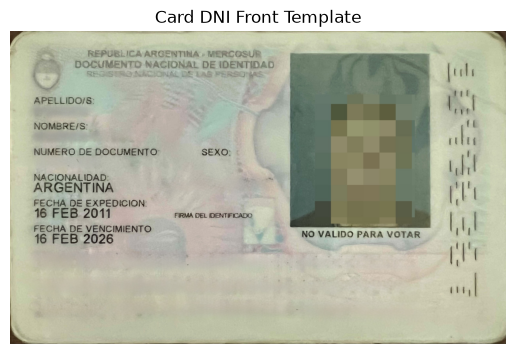

In [296]:
DNI_FRONT = "../../data/templates/front_2.jpg"

img = Image.open(DNI_FRONT)

plt.imshow(img)
plt.title("Card DNI Front Template")
plt.axis("off")  
plt.show()

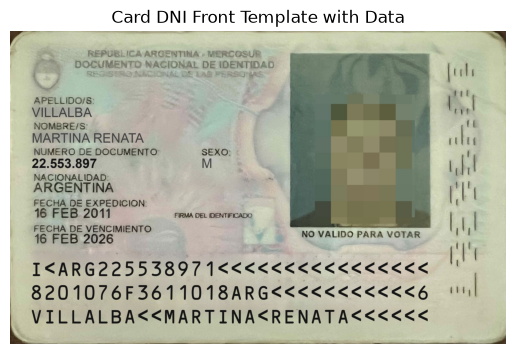

In [ ]:
font = ImageFont.truetype("../../fonts/arial.ttf", size=66)
font_bold = ImageFont.truetype("../../fonts/Arial Bold.ttf", size=66)
ocrb_font = ImageFont.truetype("../../fonts/ocrb.ttf", size=130)
img = Image.open(DNI_FRONT).convert("RGBA")
draw = ImageDraw.Draw(img)

# First name
first_name, last_name = get_parts_of_name(user)
absolute_coords = to_fixed(img, coords_data['card']['front']['LAST_NAME_COORD'])
draw_field(draw=draw,
           text=first_name.upper(),
           position=(absolute_coords[0][0], absolute_coords[0][1]),
           font=font,
           fill=(20, 20, 20, 205))

# Last name
absolute_coords = to_fixed(img, coords_data['card']['front']['FIRST_NAME_COORD'])
draw_field(draw=draw,
           text=last_name.upper(),
           position=(absolute_coords[0][0], absolute_coords[0][1]),
           font=font,
           fill=(20, 20, 20, 205))

# Document number
document_number = generate_fake_dni()
absolute_coords = to_fixed(img, coords_data['card']['front']['DOCUMENT_NUMBER_COORD'])
draw_field(draw=draw,
           text=document_number,
           position=(absolute_coords[0][0], absolute_coords[0][1]),
           font=font_bold,
           fill=(20, 20, 20))

# Sex
absolute_coords = to_fixed(img, coords_data['card']['front']['SEX_COORD'])
draw_field(draw=draw,
           text=random.choice(["M", "F"]),
           position=(absolute_coords[0][0], absolute_coords[0][1]),
           font=font,
           fill=(20, 20, 20, 205))

mrz = generate_fake_mrz(document_number, first_name, last_name)
absolute_coords = to_fixed(img, coords_data['card']['front']['MRZ_COORD'])
draw_field(draw=draw,
           text=mrz,
           position=(absolute_coords[0][0], absolute_coords[0][1]),
           font=ocrb_font,
           fill=(20, 20, 20, 255))

plt.imshow(img)
plt.title("Card DNI Front Template with Data")
plt.axis("off")
plt.show()

### **Paste a face**

Now, we will paste a face picture in our template for this type of ID.

*Notes: In this example we will use the same picture than in the previous example of this notebook*

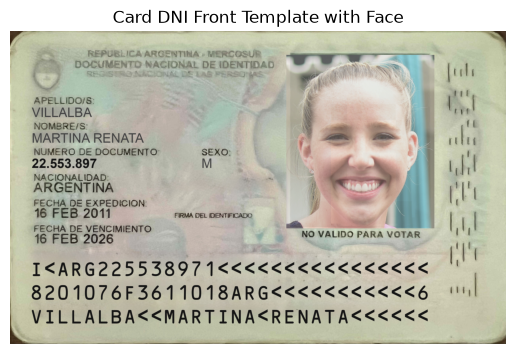

In [298]:
absolute_coords = to_fixed(img, coords_data['card']['front']['PICTURE_COORD'])

x1, y1 = absolute_coords[0]
x2, y2 = absolute_coords[1]
target_w, target_h = x2 - x1, y2 - y1

# Resize the face image + Center crop to fit the target area
face_img_a = ImageOps.fit(image=face_img.copy(),
                        size=(target_w, target_h),
                        method=Image.Resampling.LANCZOS,
                        centering=(0.5, 0.5))

# Paste the face image onto the DNI template
# img.paste(face_img, (x1, y1))
alpha = face_img_a.split()[3].point(lambda a: int(a * 0.8))
face_img_a.putalpha(alpha)
img.paste(face_img_a, (x1, y1), face_img_a)

plt.imshow(img)
plt.title("Card DNI Front Template with Face")
plt.axis("off")
plt.show()

* Save this example

In [275]:
img.save("../../data/prc/synthetic_examples/card_front.png", format="PNG")

## **Complete the back data of a DNI**

In this step, we will complete te data of the back of the document ID (fake data generated by `faker`) in their correct places.


* In first place, show the empty template.
* Put the data in their correct places (Address, *Tramite Number*)

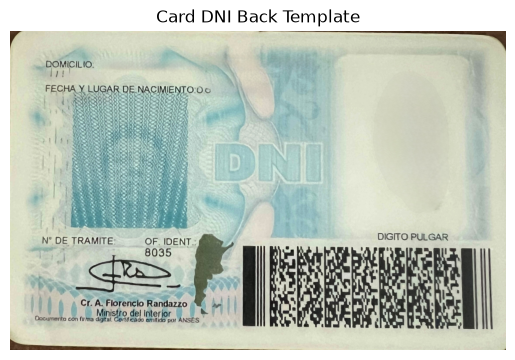

In [299]:
DNI_BACK = "../../data/templates/back_2.jpg"

img = Image.open(DNI_BACK)

plt.imshow(img)
plt.title("Card DNI Back Template")
plt.axis("off")  
plt.show()

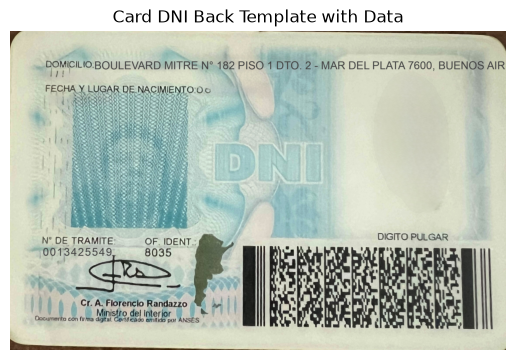

In [ ]:
font = ImageFont.truetype("../../fonts/arial.ttf", size=50)
img = Image.open(DNI_BACK).convert("RGBA")
draw = ImageDraw.Draw(img)

# Address
address = generate_fake_address(fake)
absolute_coords = to_fixed(img, coords_data['card']['back']['ADDRESS_COORD'])
draw_field(draw=draw,
           text=address.upper(),
           position=(absolute_coords[0][0], absolute_coords[0][1]),
           font=font,
           fill=(20, 20, 20, 205))

# Tramite Number
tramite_number = generate_fake_tramite_number()
absolute_coords = to_fixed(img, coords_data['card']['back']['NRO_TRAMITE_COORD'])
draw_text_with_spacing(draw=draw,
                       text=tramite_number,
                       position=(absolute_coords[0][0], absolute_coords[0][1]),
                       font=font,
                       fill=(20, 20, 20, 205),  
                       spacing=4
)

plt.imshow(img)
plt.title("Card DNI Back Template with Data")
plt.axis("off")
plt.show()

* Save this example

In [286]:
img.save("../../data/prc/synthetic_examples/card_back.png", format="PNG")